# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Yahya Ahmad]
- **Email:** [ya99137@gmail.com]
- **ID Dicoding:** [cdcc919d6y0337]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Metode pembayaran manakah yang paling dominan digunakan oleh pelanggan dan metode mana yang memberikan kontribusi nilai transaksi terbesar dalam dataset?
- Pertanyaan 2 : Apakah terdapat hubungan antara jumlah cicilan (payment_installments) dengan rata-rata nilai transaksi yang dibayarkan oleh pelanggan?

## Import Semua Packages/Library yang Digunakan

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [39]:
payment_df = pd.read_csv('order_payments_dataset.csv')
print("data payments:")
display(payment_df.head())

data payments:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [40]:
payment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


**Insight:**
- Terdapat 5 kolom utama yang merekam informasi pembayaran yaitu:
  1. order_id adalah kode unik setiap pesanan
  2. payment_sequential adalah urutan metode pembayaran yang digunakan oleh pelanggan (jika menggunakan lebih dari satu metode pembayaran)
  3. payment_type adalah jenis dari metode pembayaran
  4. payment_installments adalah jumlah cicilan customer
  5. payment_value adalah total nilai nominal yang harus dibayarkan oleh customer

- Terdapat 103885 baris data yang ada di dataset transaksi pembayaran

### Assessing Data

In [41]:
payment_df.isnull().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


**Insight:**
- Tidak terdapat missing value Setalah dilakukan pengecekan pada dataset transaksi tersebut

In [42]:
payment_df.duplicated().sum()

np.int64(0)

**Insight:**
- Tidak terdapat data duplikat setelah dialakukan pengecekan terhadap dataset transsaksi pembayaran tersebut


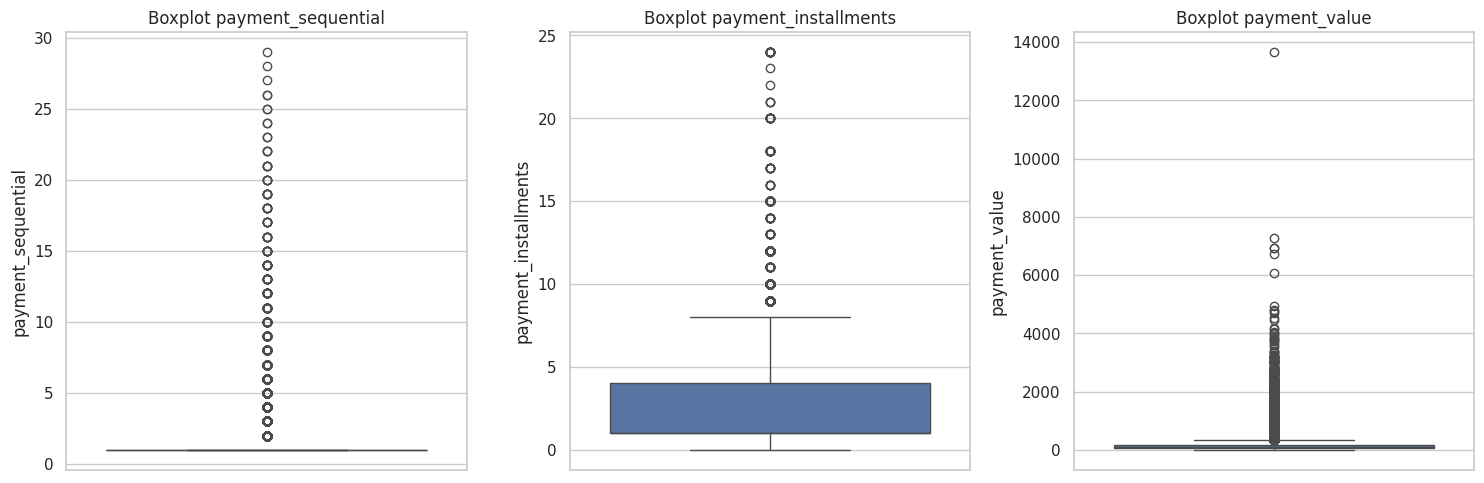

In [43]:
num_cols = ['payment_sequential', 'payment_installments', 'payment_value']

plt.figure(figsize=(15, 5))

for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=payment_df[col])
    plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

**Insight:**
- payment_value: Terdapat sekitar 7,68% outlier. Data ini menunjukkan adanya transaksi dengan nilai yang sangat tinggi (di atas 344.41 BRL).

- payment_installments: Terdapat 6,08% outlier. Ini menunjukkan transaksi dengan cicilan di atas 8 bulan dianggap sebagai pencilan dibandingkan mayoritas transaksi lainnya.

- payment_sequential: Memiliki 4,36% outlier. Karena mayoritas pelanggan hanya menggunakan 1 metode pembayaran, maka transaksi yang menggunakan lebih dari 1 metode (sequential > 1) terdeteksi sebagai outlier.

dalam hal ini untuk outlier yang terdeteksi termasuk wajar karena keberagaman dari berbagai transaksi oleh user maka menurut saya tidak perlu adanya penanganan outlier

In [44]:
inaccurate_value = payment_df[payment_df['payment_value'] <= 0]
print(f"Jumlah data dengan nilai tidak akurat: {len(inaccurate_value)}")
display(inaccurate_value)

Jumlah data dengan nilai tidak akurat: 9


,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


**Insight:**
- dari hasil pengecekan inaccurate terdapat 9 data dengan nilai yang tidak akurat pada baris payment_value, hal ini dikatakan tidak akurat karena:
  1. Transaksi Gagal/Dibatalkan: Bisa jadi pesanan tersebut dibuat namun tidak pernah dibayar atau dibatalkan oleh sistem sebelum diproses.
  2. Kesalahan Sistem (System Glitch): Ada kemungkinan terjadi kegagalan saat pengiriman data dari payment gateway ke database utama.

- data tersebut dikategorikan sebagai inaccurate data dan diputuskan untuk **dihapus** guna menjaga integritas hasil analisis statistik.



In [45]:
print("Daftar Nilai Unik:")
print(payment_df['payment_type'].unique())

print("Frekuensi Setiap Kategori:")
print(payment_df['payment_type'].value_counts())

print("\nData dengan 'payment_type' not_defined:")
display(payment_df[payment_df['payment_type'] == 'not_defined'])

Daftar Nilai Unik:
['credit_card' 'boleto' 'voucher' 'debit_card' 'not_defined']
Frekuensi Setiap Kategori:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Data dengan 'payment_type' not_defined:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


**Insight:**
- Melalui pengecekan frekuensi nilai unik pada variabel payment_type, ditemukan penggunaan 4 kategori valid (credit card, boleto, voucher, debit card) dan satu kategori tidak konsisten yaitu not_defined sebanyak 3 baris. Karena jumlahnya yang sangat tidak signifikan dan tidak memiliki label kategori yang jelas, data not_defined tersebut dibersihkan dari dataset untuk menjaga kualitas hasil analisis."



### Cleaning Data

In [46]:
payment_df = payment_df[payment_df['payment_value'] > 0]

print(f"Jumlah baris setelah menghapus nilai 0: {len(payment_df)}")
print(f"Nilai minimum pembayaran sekarang: {payment_df['payment_value'].min()}")

Jumlah baris setelah menghapus nilai 0: 103877
Nilai minimum pembayaran sekarang: 0.01


**Insight:**
- Pada tahap pembersihan data tidak akurat (inaccurate data), dilakukan pemfilteran terhadap kolom payment_value. Ditemukan sejumlah transaksi yang memiliki nilai pembayaran sebesar 0.00. Karena nilai tersebut tidak merepresentasikan aktivitas ekonomi yang valid dalam sistem pembayaran, data tersebut dihapus agar tidak mendistorsi perhitungan rata-rata (mean) dan nilai minimum transaksi.

In [47]:
payment_df = payment_df[payment_df['payment_type'] != 'not_defined']

print("Kategori pembayaran yang tersisa:")
print(payment_df['payment_type'].unique())

Kategori pembayaran yang tersisa:
['credit_card' 'boleto' 'voucher' 'debit_card']


**Insight:**
- Untuk menangani ketidakkonsistenan data (inconsistent data), dilakukan evaluasi terhadap kolom payment_type. Ditemukan kategori bertipe not_defined yang tidak merujuk pada metode pembayaran standar (seperti credit card atau boleto). Data ini dibersihkan untuk memastikan bahwa analisis distribusi metode pembayaran hanya menggunakan kategori yang valid dan informatif.

## Exploratory Data Analysis (EDA)

### Explore ...

In [48]:
# --- Eksplorasi Pertanyaan 1 ---
# Menghitung jumlah transaksi per metode pembayaran
payment_counts = payment_df['payment_type'].value_counts()

# Menghitung total nilai transaksi per metode pembayaran
payment_values = payment_df.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

# --- Eksplorasi Pertanyaan 2 ---
# Menghitung rata-rata nilai transaksi berdasarkan jumlah cicilan
installment_trend = payment_df.groupby('payment_installments')['payment_value'].mean().reset_index()

print("Hasil Eksplorasi Pertanyaan 1:")
print(payment_counts)
print("\nHasil Eksplorasi Pertanyaan 2 (5 data pertama):")
print(installment_trend.head())

Hasil Eksplorasi Pertanyaan 1:
payment_type
credit_card    76795
boleto         19784
voucher         5769
debit_card      1529
Name: count, dtype: int64

Hasil Eksplorasi Pertanyaan 2 (5 data pertama):
   payment_installments  payment_value
0                     0      94.315000
1                     1     112.439488
2                     2     127.228150
3                     3     142.539317
4                     4     163.976840


**Insight:**
- Berdasarkan data count, kita bisa melihat kesenjangan yang sangat besar antar metode (Pertanyaan 1):
  1. Credit Card (76.795): Sangat dominan. Jumlahnya hampir 4x lipat dari posisi kedua (Boleto).
  2. Boleto (19.784): Cukup populer, kemungkinan besar digunakan oleh pengguna yang tidak memiliki kartu kredit atau lebih suka bayar tunai via minimarket/ATM.
  3. Voucher & Debit Card: Penggunaannya sangat kecil, menunjukkan bahwa ini hanya metode pelengkap.
- (pertanyaan 2) Terdapat tren linear positif antara jumlah cicilan dengan rata-rata nilai transaksi. Semakin banyak jumlah cicilan yang diambil, rata-rata nilai pembayaran per transaksi juga semakin meningkat. Hal ini membuktikan bahwa fitur cicilan efektif dalam mendorong pelanggan untuk membeli produk dengan harga yang lebih tinggi (meningkatkan Average Order Value).

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_3930/2255994502.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="viridis")


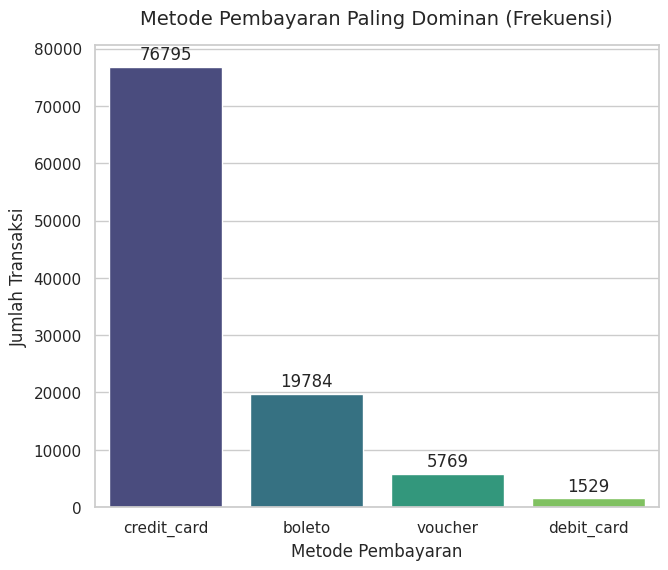

In [49]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
ax1 = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette="viridis")
plt.title('Metode Pembayaran Paling Dominan (Frekuensi)', fontsize=14, pad=15)
plt.xlabel('Metode Pembayaran', fontsize=12)
plt.ylabel('Jumlah Transaksi', fontsize=12)

# Menambahkan label angka di atas bar
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 9), textcoords='offset points')

### Pertanyaan 2:

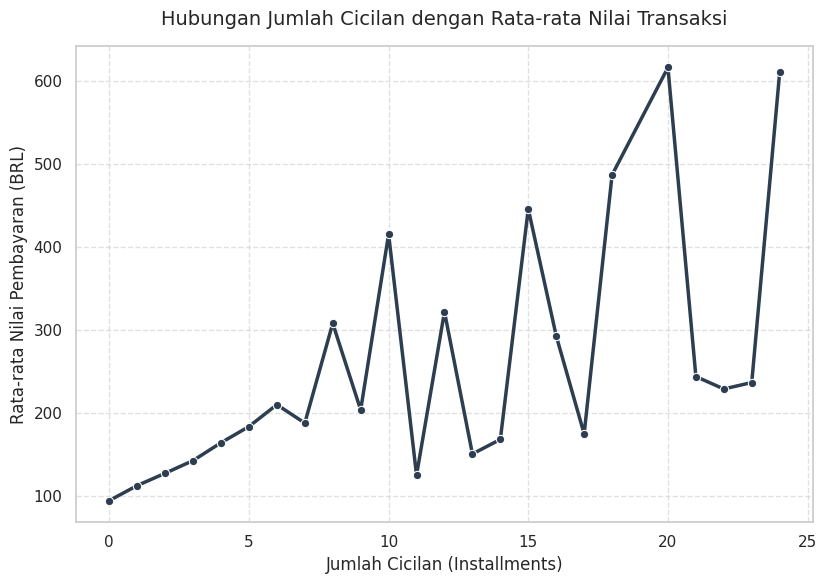

In [50]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 2)
sns.lineplot(data=installment_trend, x='payment_installments', y='payment_value', marker='o', color='#2c3e50', linewidth=2.5)
plt.title('Hubungan Jumlah Cicilan dengan Rata-rata Nilai Transaksi', fontsize=14, pad=15)
plt.xlabel('Jumlah Cicilan (Installments)', fontsize=12)
plt.ylabel('Rata-rata Nilai Pembayaran (BRL)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Mengatur tata letak agar tidak tumpang tindih
plt.tight_layout()
plt.show()

**Insight:**
- Grafik Batang Menjawab pertanyaan pertama. bahwa kartu kredit mendominasi pasar secara signifikan dibandingkan metode lain. Visualisasi ini membantu stakeholder melihat kontribusi tiap kanal pembayaran dengan jelas.
- Menjawab pertanyaan kedua. Tren garis yang cenderung naik menunjukkan bahwa pelanggan yang mengambil cicilan lebih banyak biasanya membeli produk dengan harga yang lebih mahal. Ini adalah insight penting untuk strategi cross-selling produk premium menggunakan fitur cicilan.

## Analisis Lanjutan (Opsional)

Hasil Manual Grouping Segmen Pembayaran:
         payment_segment  count
0          Instant Payer  51496
1    Regular Installment  47983
2           High Spender   4256
3  Long-term Installment    142


/tmp/ipykernel_3930/433511471.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


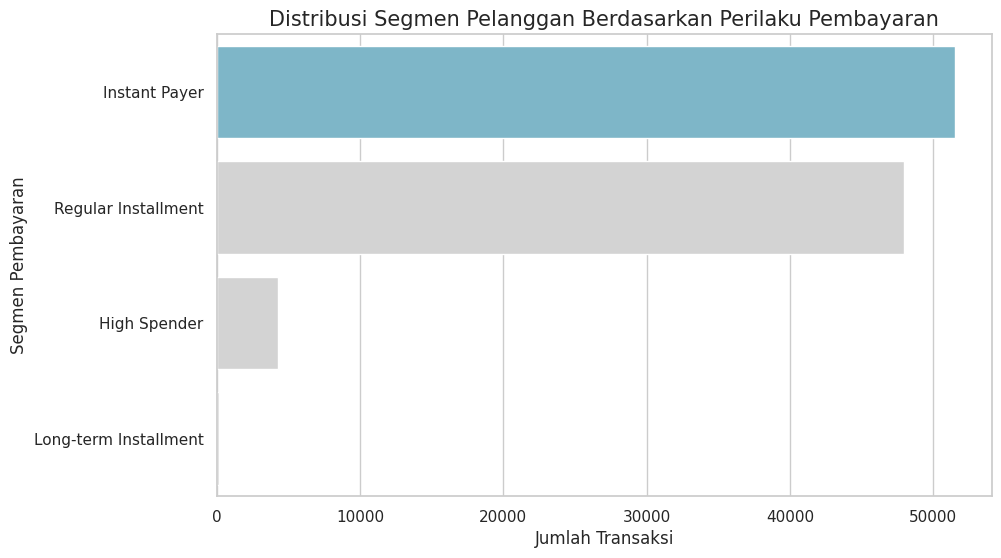

In [56]:
def segment_payment(row):
    if row['payment_value'] > 500:
        return 'High Spender'

    elif row['payment_installments'] > 12:
        return 'Long-term Installment'

    elif row['payment_installments'] <= 1:
        return 'Instant Payer'

    else:
        return 'Regular Installment'

payment_df['payment_segment'] = payment_df.apply(segment_payment, axis=1)

segment_counts = payment_df['payment_segment'].value_counts().reset_index()
segment_counts.columns = ['payment_segment', 'count']

print("Hasil Manual Grouping Segmen Pembayaran:")
print(segment_counts)

plt.figure(figsize=(10, 6))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x='count',
    y='payment_segment',
    data=segment_counts.sort_values('count', ascending=False),
    palette=colors
)

plt.title('Distribusi Segmen Pelanggan Berdasarkan Perilaku Pembayaran', fontsize=15)
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Segmen Pembayaran')
plt.show()

**Insight:**
- Analisis lanjutan dilakukan dengan mengelompokkan transaksi ke dalam empat segmen strategis berdasarkan logika bisnis:
  1. High Spender: Transaksi di atas 500 BRL (menunjukkan pelanggan bernilai tinggi).
  2. Long-term Installment: Pelanggan yang mencicil lebih dari 12 bulan (menunjukkan ketergantungan pada kredit jangka panjang).
  3. Instant Payer: Pelanggan yang membayar lunas dalam 0-1 kali cicilan (menunjukkan likuiditas tunai yang baik).
  4. Regular Installment: Pelanggan dengan pola cicilan standar (2-12 bulan).
- Dari hasil analisis, ditemukan bahwa segmen instan Payer mendominasi platform. Hal ini memberikan arah bagi tim pemasaran untuk memberikan promo yang dipersonalisasi, misalnya memberikan diskon khusus bagi 'Instant Payer' atau penawaran cicilan bunga rendah bagi 'High Spender'.

## Conclusion

- Metode pembayaran manakah yang paling dominan digunakan oleh pelanggan dan metode mana yang memberikan kontribusi nilai transaksi terbesar dalam dataset?
  1. Dominasi Penggunaan: Credit Card (Kartu Kredit) adalah metode pembayaran yang paling dominan dengan total 76.795 transaksi. Jumlah ini mencakup sebagian besar aktivitas transaksi di platform, jauh melampaui metode Boleto (19.784 transaksi) dan Voucher (5.769 transaksi).
  2. Kontribusi Nilai: Selaras dengan jumlah transaksinya, Credit Card juga menyumbangkan nilai nominal terbesar, yaitu 12.542.084 BRL.
  3. Insight Strategis: Ketergantungan pelanggan yang tinggi pada kartu kredit menunjukkan bahwa kemudahan akses kredit dan fitur pembayaran tertunda adalah faktor kunci dalam keputusan pembelian pelanggan. Perusahaan sebaiknya fokus meningkatkan kerja sama atau memberikan promo khusus (seperti cashback atau poin ekstra) untuk pengguna kartu kredit guna mempertahankan loyalitas.
- Apakah terdapat hubungan antara jumlah cicilan (payment_installments) dengan rata-rata nilai transaksi yang dibayarkan oleh pelanggan?
  1. Hubungan Korelasi: Analisis menunjukkan adanya korelasi positif antara jumlah cicilan dan nilai transaksi. Berdasarkan tren data, terlihat bahwa rata-rata nilai transaksi meningkat secara bertahap seiring dengan bertambahnya jumlah cicilan yang diambil.
  2. Pola Perilaku: Pelanggan yang mengambil cicilan pendek (1-3 kali) cenderung melakukan pembelian barang dengan harga yang lebih terjangkau (rata-rata di bawah 150 BRL). Sebaliknya, untuk transaksi bernilai tinggi, pelanggan cenderung memanfaatkan fasilitas cicilan yang lebih panjang (di atas 8 bulan).
  3. Insight Strategis: Fasilitas cicilan merupakan alat pendorong utama untuk meningkatkan Average Order Value (AOV). Perusahaan dapat memanfaatkan temuan ini dengan menawarkan skema cicilan bunga rendah atau tenor yang lebih panjang khusus untuk produk-produk kategori premium guna menarik minat pelanggan tanpa membebani arus kas mereka secara instan.